# **Machine** **Learning** **Analysis** **of** **Student** **Placement**

##Overview:-

**The Student Placement dataset contains information about students’ academics, technical skills, soft skills, and their project or internship experience. By analyzing this data, we can understand overall student performance, identify the key factors that influence placement results, and find areas where students may need improvement. This analysis helps colleges and training teams understand what skills matter most for getting placed and supports better planning to improve student employability and placement outcomes.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
train=pd.read_csv('train_student.csv')

In [3]:
test=pd.read_csv('test_student.csv')

In [4]:
train.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Unnamed: 15,Unnamed: 16
0,1048.0,22.0,Female,B.Tech,ECE,6.29,0.0,3.0,4.0,6.0,51.0,5.0,1.0,3.0,Not Placed,NaN,NaN
1,37820.0,20.0,Female,BCA,ECE,6.05,1.0,4.0,6.0,NaN,59.0,8.0,2.0,1.0,Not Placed,NaN,NaN
2,49668.0,22.0,Male,MCA,ME,7.22,1.0,4.0,6.0,6.0,58.0,6.0,2.0,2.0,Not Placed,NaN,NaN
3,19467.0,22.0,Male,MCA,ME,7.78,2.0,4.0,6.0,6.0,90.0,4.0,2.0,0.0,NaN,NaN,NaN
4,23094.0,20.0,Female,B.Tech,ME,NaN,1.0,4.0,6.0,5.0,79.0,6.0,NaN,0.0,Placed,NaN,NaN


In [5]:
test.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
0,15202.0,23.0,Male,B.Tech,Civil,7.32,2.0,4.0,5.0,6.0,NaN,6.0,1.0,0.0
1,4573.0,24.0,Female,MCA,ME,4.76,0.0,1.0,1.0,4.0,37.0,4.0,0.0,3.0
2,34424.0,20.0,Male,BCA,ME,6.16,0.0,3.0,3.0,8.0,68.0,6.0,1.0,3.0
3,38881.0,19.0,Male,B.Sc,IT,8.77,NaN,5.0,8.0,5.0,NaN,NaN,3.0,0.0
4,30191.0,23.0,Male,NaN,ME,7.63,0.0,3.0,4.0,6.0,66.0,7.0,1.0,0.0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            43047 non-null  float64
 1   Age                   43040 non-null  float64
 2   Gender                43043 non-null  object 
 3   Degree                42988 non-null  object 
 4   Branch                43063 non-null  object 
 5   CGPA                  43080 non-null  float64
 6   Internships           43011 non-null  float64
 7   Projects              43053 non-null  float64
 8   Coding_Skills         43019 non-null  float64
 9   Communication_Skills  42996 non-null  float64
 10  Aptitude_Test_Score   43021 non-null  float64
 11  Soft_Skills_Rating    43013 non-null  float64
 12  Certifications        43030 non-null  float64
 13  Backlogs              43020 non-null  float64
 14  Placement_Status      42993 non-null  object 
 15  Unnamed: 15        

In [7]:
train.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Unnamed: 15
count,43047.000000,43040.000000,43080.000000,43011.000000,43053.000000,43019.000000,42996.000000,43021.000000,43013.000000,43030.000000,43020.000000,0.0
mean,25019.661115,21.001441,7.002515,0.773221,3.734583,5.691997,5.503163,69.382395,5.502569,1.800302,0.888866,NaN
std,14420.091793,1.994392,0.994715,0.844144,0.923891,1.992716,1.515241,13.918702,1.237426,0.650094,0.970899,NaN
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000,NaN
25%,12576.500000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000,NaN
50%,25004.000000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,6.000000,2.000000,1.000000,NaN
75%,37530.500000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000,NaN
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000,NaN


In [8]:
train.isnull().sum()/len(train)*100

,0
Student_ID,4.340000
Age,4.355556
Gender,4.348889
Degree,4.471111
Branch,4.304444
CGPA,4.266667
Internships,4.420000
Projects,4.326667
Coding_Skills,4.402222
Communication_Skills,4.453333


In [9]:
train.shape

(45000, 17)

In [10]:
test.shape

(5000, 14)

In [11]:
cat_col=train.select_dtypes(include='object').columns
cat_col

Index(['Gender', 'Degree', 'Branch', 'Placement_Status', 'Unnamed: 16'], dtype='object')

In [12]:
train['Gender']=train['Gender'].fillna(train['Gender'].mode()[0])

In [13]:
train['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [14]:
train['Degree']=train['Degree'].fillna(train['Degree'].mode()[0])

In [15]:
train['Degree'].unique()

array(['B.Tech', 'BCA', 'MCA', 'B.Sc'], dtype=object)

In [16]:
train['Branch']=train['Branch'].fillna(train['Branch'].mode()[0])

In [17]:
train['Branch'].unique()

array(['ECE', 'ME', 'Civil', 'IT', 'CSE'], dtype=object)

In [18]:
train['Placement_Status']=train['Placement_Status'].fillna(train['Placement_Status'].mode()[0])

In [19]:
train['Placement_Status'].unique()

array(['Not Placed', 'Placed'], dtype=object)

In [20]:
num_col=train.select_dtypes(include='float').columns
num_col

Index(['Student_ID', 'Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs', 'Unnamed: 15'],
      dtype='object')

In [21]:
train['Age']=train['Age'].fillna(train['Age'].mean()).astype(int)

In [22]:
train['CGPA']=train['CGPA'].fillna(train['CGPA'].mean())

In [23]:
train['Internships']=train['Internships'].fillna(train['Internships'].mean()).astype(int)

In [24]:
train['Projects']=train['Projects'].fillna(train['Projects'].mean()).astype(int)

In [25]:
train['Coding_Skills']=train['Coding_Skills'].fillna(train['Coding_Skills'].mean()).astype(int)

In [26]:
train['Communication_Skills']=train['Communication_Skills'].fillna(train['Communication_Skills'].mean()).astype(int)

In [27]:
train['Aptitude_Test_Score']=train['Aptitude_Test_Score'].fillna(train['Aptitude_Test_Score'].mean()).astype(int)

In [28]:
train['Soft_Skills_Rating']=train['Soft_Skills_Rating'].fillna(train['Soft_Skills_Rating'].mean())

In [29]:
train['Certifications']=train['Certifications'].fillna(train['Certifications'].mean()).astype(int)

In [30]:
train['Backlogs']=train['Backlogs'].fillna(train['Backlogs'].mean()).astype(int)

In [31]:
cols_to_drop=['Student_ID','Unnamed: 15','Unnamed: 16']

In [32]:
train.drop(cols_to_drop,axis=1,inplace=True)

In [33]:
train.isnull().sum()/len(train)*100

,0
Age,0.0
Gender,0.0
Degree,0.0
Branch,0.0
CGPA,0.0
Internships,0.0
Projects,0.0
Coding_Skills,0.0
Communication_Skills,0.0
Aptitude_Test_Score,0.0


In [34]:
cat_col=train.select_dtypes(include='object').columns
cat_col

Index(['Gender', 'Degree', 'Branch', 'Placement_Status'], dtype='object')

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat_col:
   train[i]=le.fit_transform(train[i])

In [36]:
train['Placement_Status'].unique()

array([0, 1])

#**EDA**

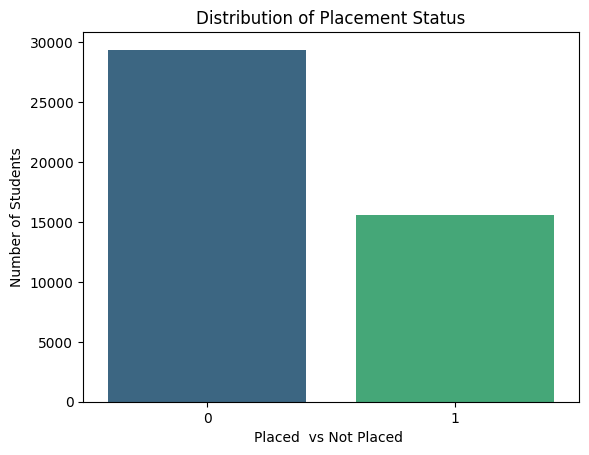

In [37]:
#To see how many students actually got placed versus those who did not.
sns.countplot(x='Placement_Status', data=train, palette='viridis')
plt.title('Distribution of Placement Status')
plt.xlabel('Placed  vs Not Placed ')
plt.ylabel('Number of Students')
plt.show()

It tells us if the data is balanced. If one bar is much taller than the other, our model might become biased toward that outcome.

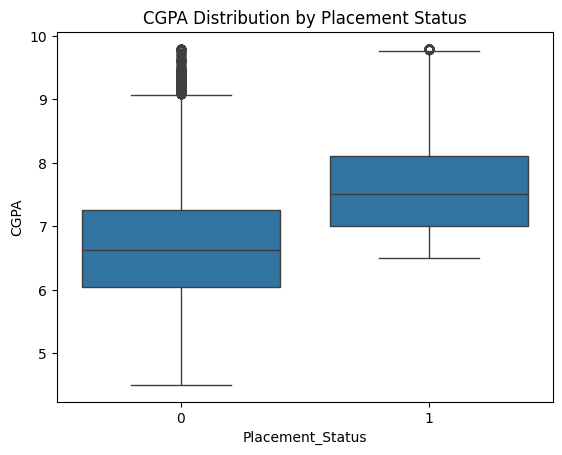

In [38]:
# To understand if higher grades really lead to better placement chances.
sns.boxplot(x='Placement_Status', y='CGPA', data=train)
plt.title('CGPA Distribution by Placement Status')
plt.show()

The box plot shows the middle range of grades. If the Placed box is higher up on the CGPA axis than the Not Placed box, it proves that students with higher CGPAs are more likely to get jobs.

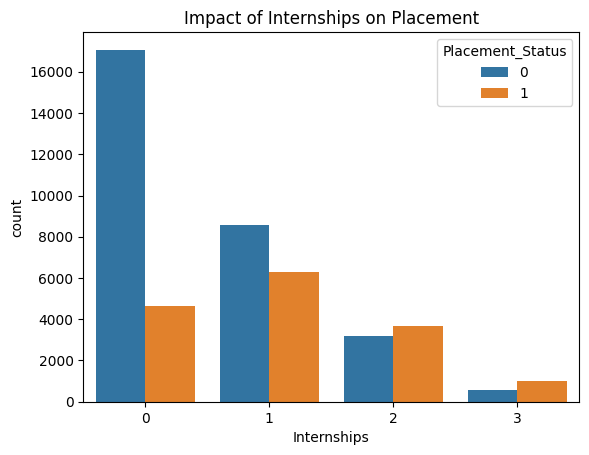

In [39]:
# To see the impact of work experience means Internships on getting hired.
sns.countplot(x='Internships', hue='Placement_Status', data=train)
plt.title('Impact of Internships on Placement')
plt.show()

This chart compares students with 0, 1, or 2+ internships. You will likely notice that as the number of internships increases, the orange bar (Placed) becomes much taller than the blue bar (Not Placed), showing that experience matters.

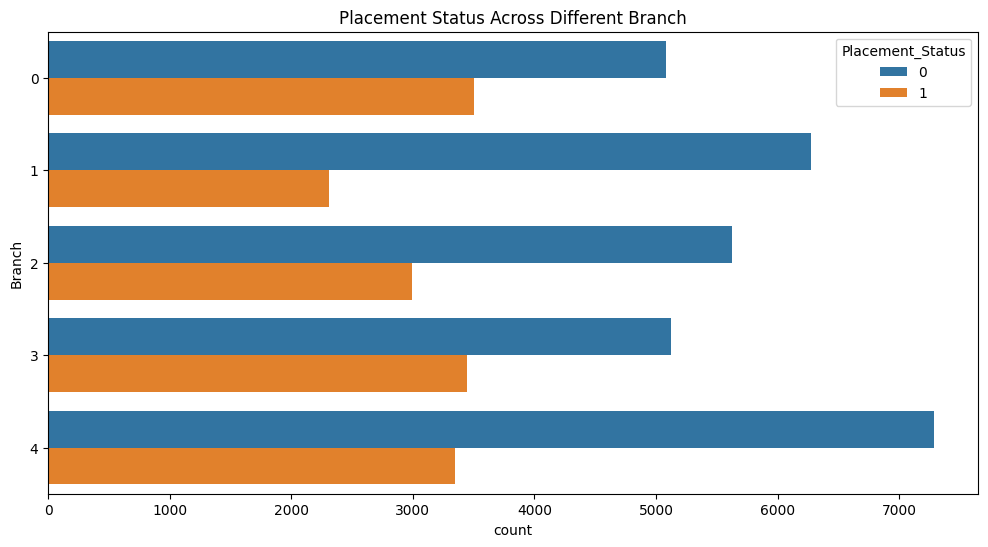

In [40]:
# To see which branch (Computer Science, IT, Mechanical, etc.) has the highest placement rate.
plt.figure(figsize=(12, 6))
sns.countplot(y='Branch', hue='Placement_Status', data=train)
plt.title('Placement Status Across Different Branch')
plt.show()

This chart lists the departments on the side. It helps us identify if certain fields (like CSE or IT) have an easier time getting placed compared to others.

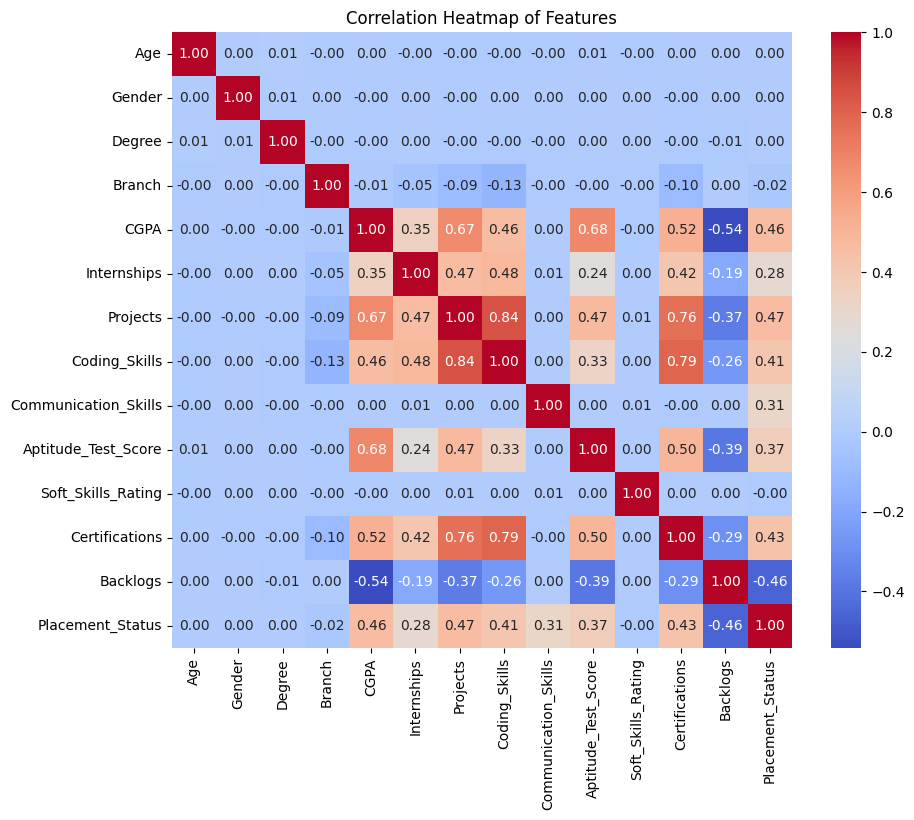

In [41]:
# To see which features are most "connected" to each other.
plt.figure(figsize=(10, 8))
correlation = train.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

# Model Building

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [43]:
x=train.iloc[:,:-1]
y=train.iloc[:,-1]

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=100)

In [45]:
x_train.shape,y_train.shape

((36000, 13), (36000,))

In [46]:
x_test.shape,y_test.shape

((9000, 13), (9000,))

In [47]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [48]:
def model_creation(model):
  model.fit(x_train,y_train)
  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)
  print("Train Data")
  print(classification_report(y_train,y_train_pred))
  print("Test Data")
  print(classification_report(y_test,y_test_pred))

In [49]:
lr=LogisticRegression()
model_creation(lr)

Train Data
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     23522
           1       0.78      0.75      0.77     12478

    accuracy                           0.84     36000
   macro avg       0.83      0.82      0.82     36000
weighted avg       0.84      0.84      0.84     36000

Test Data
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      5873
           1       0.79      0.75      0.77      3127

    accuracy                           0.84      9000
   macro avg       0.83      0.82      0.82      9000
weighted avg       0.84      0.84      0.84      9000



In [50]:
knn=KNeighborsClassifier(n_neighbors=10)
model_creation(knn)

Train Data
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     23522
           1       0.89      0.94      0.91     12478

    accuracy                           0.94     36000
   macro avg       0.93      0.94      0.93     36000
weighted avg       0.94      0.94      0.94     36000

Test Data
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5873
           1       0.86      0.92      0.89      3127

    accuracy                           0.92      9000
   macro avg       0.91      0.92      0.92      9000
weighted avg       0.92      0.92      0.92      9000



In [51]:
s1=SVC()
model_creation(s1)

Train Data
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     23522
           1       0.91      0.97      0.94     12478

    accuracy                           0.96     36000
   macro avg       0.95      0.96      0.96     36000
weighted avg       0.96      0.96      0.96     36000

Test Data
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      5873
           1       0.91      0.98      0.94      3127

    accuracy                           0.96      9000
   macro avg       0.95      0.96      0.95      9000
weighted avg       0.96      0.96      0.96      9000



In [52]:
dt=DecisionTreeClassifier()
model_creation(dt)

Train Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23522
           1       1.00      1.00      1.00     12478

    accuracy                           1.00     36000
   macro avg       1.00      1.00      1.00     36000
weighted avg       1.00      1.00      1.00     36000

Test Data
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5873
           1       0.93      0.91      0.92      3127

    accuracy                           0.95      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.95      0.95      0.95      9000



In [53]:
dt.feature_importances_

array([0.01152044, 0.00353356, 0.00885476, 0.00727273, 0.24921944,
       0.00526259, 0.00336695, 0.22538904, 0.2398829 , 0.07438352,
       0.00929559, 0.00619089, 0.15582757])

In [54]:
train_imp=pd.DataFrame({
    "Column_name":x.columns,
    "Importance":dt.feature_importances_
})

In [55]:
train_imp=train_imp.sort_values(by="Importance",ascending=False)

In [56]:
param_grid={
    "criterion":['gini','entropy'],
    "max_depth":np.arange(1,51,5),
    "min_samples_leaf":[3,6,9,12,15],
    "min_samples_split":[2,4,6,8,10]
}

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
grid=GridSearchCV(dt,param_grid=param_grid,scoring="f1_macro",cv=5,n_jobs=-1)

In [59]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 1,  6, 11, 16, 21, 26, 31, 36, 41, 46]),
                         'min_samples_leaf': [3, 6, 9, 12, 15],
                         'min_samples_split': [2, 4, 6, 8, 10]},
             scoring='f1_macro')

In [60]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': np.int64(11),
 'min_samples_leaf': 9,
 'min_samples_split': 2}

In [61]:
grid.best_score_

np.float64(0.9700803144645779)

In [62]:
dt1=DecisionTreeClassifier(criterion='entropy',
 max_depth=np.int64(11),
 min_samples_leaf= 15,
 min_samples_split= 2)

In [63]:
model_creation(dt1)

Train Data
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     23522
           1       0.93      1.00      0.96     12478

    accuracy                           0.97     36000
   macro avg       0.96      0.98      0.97     36000
weighted avg       0.97      0.97      0.97     36000

Test Data
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      5873
           1       0.93      1.00      0.96      3127

    accuracy                           0.97      9000
   macro avg       0.96      0.98      0.97      9000
weighted avg       0.98      0.97      0.97      9000



In [64]:
train['Placement_Status'].value_counts()

,count
Placement_Status,
0,29395
1,15605


In [65]:
train_majority=train[train['Placement_Status']==0]
train_minority=train[train['Placement_Status']==1]

In [66]:
# train Mojarity

In [67]:
# train Miniority

In [68]:
from sklearn.utils import resample

In [69]:
# UPsampling minorty Class
train_upsample_minority=resample(train_minority,replace=True,n_samples=23951,random_state=0)

In [70]:
# train_upsample_minority

In [71]:
train_upsampled=pd.concat([train_majority,train_upsample_minority])

In [72]:
train_upsampled.shape

(53346, 14)

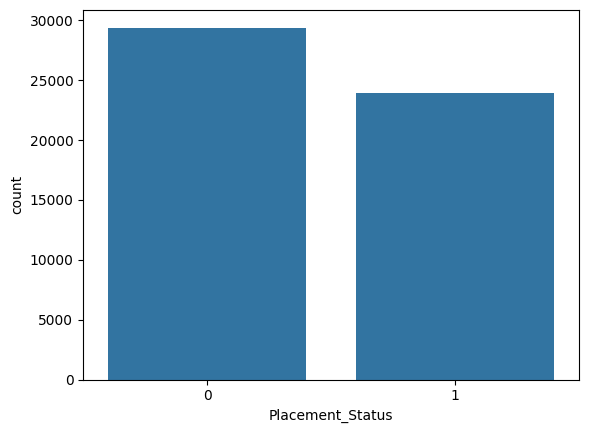

In [73]:
sns.countplot(x=train_upsampled['Placement_Status'])
plt.show()

# Test Data

In [74]:
test=pd.read_csv('test_student.csv')

In [75]:
test.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
0,15202.0,23.0,Male,B.Tech,Civil,7.32,2.0,4.0,5.0,6.0,NaN,6.0,1.0,0.0
1,4573.0,24.0,Female,MCA,ME,4.76,0.0,1.0,1.0,4.0,37.0,4.0,0.0,3.0
2,34424.0,20.0,Male,BCA,ME,6.16,0.0,3.0,3.0,8.0,68.0,6.0,1.0,3.0
3,38881.0,19.0,Male,B.Sc,IT,8.77,NaN,5.0,8.0,5.0,NaN,NaN,3.0,0.0
4,30191.0,23.0,Male,NaN,ME,7.63,0.0,3.0,4.0,6.0,66.0,7.0,1.0,0.0


In [76]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            4610 non-null   float64
 1   Age                   4622 non-null   float64
 2   Gender                4595 non-null   object 
 3   Degree                4574 non-null   object 
 4   Branch                4615 non-null   object 
 5   CGPA                  4615 non-null   float64
 6   Internships           4580 non-null   float64
 7   Projects              4619 non-null   float64
 8   Coding_Skills         4609 non-null   float64
 9   Communication_Skills  4574 non-null   float64
 10  Aptitude_Test_Score   4610 non-null   float64
 11  Soft_Skills_Rating    4589 non-null   float64
 12  Certifications        4614 non-null   float64
 13  Backlogs              4616 non-null   float64
dtypes: float64(11), object(3)
memory usage: 547.0+ KB


In [77]:
test.isnull().sum()

,0
Student_ID,390
Age,378
Gender,405
Degree,426
Branch,385
CGPA,385
Internships,420
Projects,381
Coding_Skills,391
Communication_Skills,426


In [78]:
test.isnull().sum()/len(test)*100

,0
Student_ID,7.80
Age,7.56
Gender,8.10
Degree,8.52
Branch,7.70
CGPA,7.70
Internships,8.40
Projects,7.62
Coding_Skills,7.82
Communication_Skills,8.52


In [79]:
cat_col=test.select_dtypes(include='object').columns
cat_col

Index(['Gender', 'Degree', 'Branch'], dtype='object')

In [80]:
test['Gender']=test['Gender'].fillna(test['Gender'].mode()[0])

In [81]:
test['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [82]:
test['Degree']=test['Degree'].fillna(test['Degree'].mode()[0])

In [83]:
test['Degree'].unique()

array(['B.Tech', 'MCA', 'BCA', 'B.Sc'], dtype=object)

In [84]:
test['Branch']=test['Branch'].fillna(test['Branch'].mode()[0])

In [85]:
test['Branch'].unique()

array(['Civil', 'ME', 'IT', 'CSE', 'ECE'], dtype=object)

In [86]:
num_col=test.select_dtypes(include='float').columns
num_col

Index(['Student_ID', 'Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')

In [87]:
test['Student_ID']=test['Student_ID'].fillna(test['Student_ID'].mean())

In [88]:
test['Age']=test['Age'].fillna(test['Age'].mean()).astype(int)

In [89]:
test['CGPA']=test['CGPA'].fillna(test['CGPA'].mean())

In [90]:
test['Internships']=test['Internships'].fillna(test['Internships'].mean()).astype(int)

In [91]:
test['Projects']=test['Projects'].fillna(test['Projects'].mean()).astype(int)

In [92]:
test['Coding_Skills']=test['Coding_Skills'].fillna(test['Coding_Skills'].mean()).astype(int)

In [93]:
test['Communication_Skills']=test['Communication_Skills'].fillna(test['Communication_Skills'].mean()).astype(int)

In [94]:
test['Aptitude_Test_Score']=test['Aptitude_Test_Score'].fillna(test['Aptitude_Test_Score'].mean()).astype(int)

In [95]:
test['Soft_Skills_Rating']=test['Soft_Skills_Rating'].fillna(test['Soft_Skills_Rating'].mean())

In [96]:
test['Certifications']=test['Certifications'].fillna(test['Certifications'].mean()).astype(int)

In [97]:
test['Backlogs']=test['Backlogs'].fillna(test['Backlogs'].mean()).astype(int)

In [98]:
test.isnull().sum()/len(train)*100

,0
Student_ID,0.0
Age,0.0
Gender,0.0
Degree,0.0
Branch,0.0
CGPA,0.0
Internships,0.0
Projects,0.0
Coding_Skills,0.0
Communication_Skills,0.0


In [99]:
final=test[['Student_ID']]

In [100]:
final

,Student_ID
0,15202.0
1,4573.0
2,34424.0
3,38881.0
4,30191.0
...,...
4995,40640.0
4996,46999.0
4997,3816.0
4998,41368.0


In [101]:
test.drop(['Student_ID'],axis=1,inplace=True)

In [102]:
cat_col=test.select_dtypes(include=["O"]).columns
cat_col

Index(['Gender', 'Degree', 'Branch'], dtype='object')

In [103]:
from sklearn.preprocessing import LabelEncoder

In [104]:
le=LabelEncoder()

In [105]:
for i in cat_col:
  test[i]=le.fit_transform(test[i])

In [106]:
for i in cat_col:
  print(i)

Gender
Degree
Branch


In [107]:
y_pred=dt1.predict(test)

In [108]:
len(y_pred)

5000

In [109]:
final_df=pd.DataFrame(data=y_pred)
final_df

,0
0,1
1,0
2,0
3,1
4,1
...,...
4995,0
4996,1
4997,1
4998,1


In [110]:
final['Placement Status']=y_pred

In [111]:
final

,Student_ID,Placement Status
0,15202.0,1
1,4573.0,0
2,34424.0,0
3,38881.0,1
4,30191.0,1
...,...,...
4995,40640.0,0
4996,46999.0,1
4997,3816.0,1
4998,41368.0,1


In [112]:
import pickle
fp=open("model.pkl","wb")